In [37]:
#packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, roc_auc_score

## Loading the dataset and doing some exploratory analysis

In [38]:
#loading dataset into a pandas DataFrame
df = pd.read_csv('creditcard.csv')

#relevant information on the data
print(f'Shape: {df.shape} \n')
print(df['Class'].value_counts())
#0 is legit, 1 is fraud
fraud_count = df['Class'].value_counts()[1]
legit_count = df['Class'].value_counts()[0]
print(f'Fraud Percent: {fraud_count/(fraud_count + legit_count)}')
print("\nNull counts:")
print(df.isnull().sum())
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'creditcard.csv'

## Important Information
There are not many fraud entries in the dataset (around 0.17%), meaning that I will have to ensure:
- testing and training sets each have an adequate number of fraud entries
- the model doesn't default to labeling everything as legit for high accuracy

## Features
Time: Number of seconds elapsed between this transaction and the first transaction in the dataset  
V1 - V28: User features - may be result of a PCA Dimensionality reduction to protect user identities and sensitive  
Amount: Purchase price

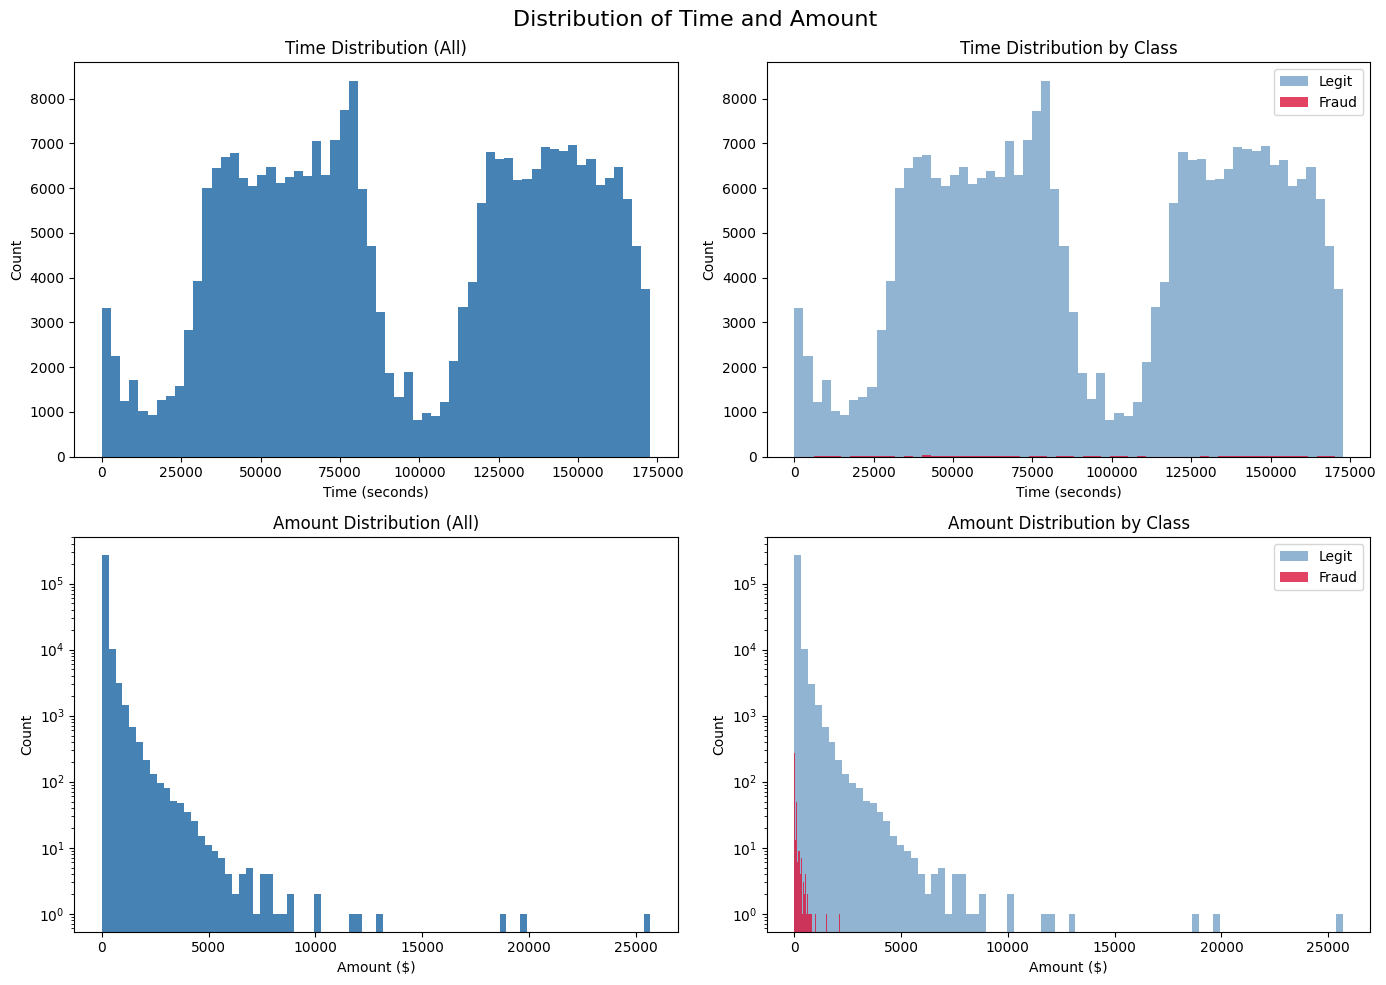

Time  — mean: 94813.9s, median: 84692.0s
Amount — mean: $88.35, median: $22.00
Fraud Amount — mean: $122.21, median: $9.25


In [ ]:
# AI Generated Cell

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Time and Amount', fontsize=16)

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

# Time - overall
axes[0, 0].hist(df['Time'], bins=60, color='steelblue', edgecolor='none')
axes[0, 0].set_title('Time Distribution (All)')
axes[0, 0].set_xlabel('Time (seconds)')
axes[0, 0].set_ylabel('Count')

# Time - by class
axes[0, 1].hist(legit['Time'], bins=60, alpha=0.6, label='Legit', color='steelblue', edgecolor='none')
axes[0, 1].hist(fraud['Time'], bins=60, alpha=0.8, label='Fraud', color='crimson', edgecolor='none')
axes[0, 1].set_title('Time Distribution by Class')
axes[0, 1].set_xlabel('Time (seconds)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# Amount - overall (log scale for readability)
axes[1, 0].hist(df['Amount'], bins=80, color='steelblue', edgecolor='none')
axes[1, 0].set_title('Amount Distribution (All)')
axes[1, 0].set_xlabel('Amount ($)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_yscale('log')

# Amount - by class
axes[1, 1].hist(legit['Amount'], bins=80, alpha=0.6, label='Legit', color='steelblue', edgecolor='none')
axes[1, 1].hist(fraud['Amount'], bins=80, alpha=0.8, label='Fraud', color='crimson', edgecolor='none')
axes[1, 1].set_title('Amount Distribution by Class')
axes[1, 1].set_xlabel('Amount ($)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Time  — mean: {df['Time'].mean():.1f}s, median: {df['Time'].median():.1f}s")
print(f"Amount — mean: ${df['Amount'].mean():.2f}, median: ${df['Amount'].median():.2f}")
print(f"Fraud Amount — mean: ${fraud['Amount'].mean():.2f}, median: ${fraud['Amount'].median():.2f}")

## Interesting notes:
The median fraud purchases are actually much lower than the medain of legit purchases. Yet there seem to be some high outliers that drag the mean higher.
The time also shows that the fraud purchases are evenly spaced out, and don't follow the trend of legit purchases. 

Before going into making a model, I will have to do some data transformations - I will scale time and amount in my dataset to follow the PCA that has already been done on the other features in the dataset. 

In [28]:
#Scaling
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

#print(df.value_counts(df['Amount']))
#print(df.value_counts(df['Time']))

X = df.drop('Class', axis=1).values
y = df['Class'].values

#stratify=y is important here so both train and test have enough fraud datapoints to work on
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# To ensure that the model doesn't label ever entry as legit to achieve high accuracy, I will assign class weights to fraud entries
# If they are missed they will result in higher loss, and better updates with the loss function
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
#print(pos_weight)

## Model Creation

In [29]:
class FraudMLP(nn.Module):
    def __init__(self, input_dim=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)
    
learning_rate = 1e-3

## Convert to tensors

Since I am using pytorch for this, I will have to load the data as tensors

In [30]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=256)

## loss function and optimizer

BCEWithLogitsLoss is more numerically stable than BCELoss with Sigmoid  

In [31]:
model = FraudMLP(input_dim=X_train.shape[1])

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], dtype=torch.float32))
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

## Training loop

Each epoch: 
- forward pass
- compute loss 
- backpropagate gradients 
- update weights

In [32]:
EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  loss: {avg_loss:.4f}")

Epoch   5/30  loss: 0.2373
Epoch  10/30  loss: 0.1692
Epoch  15/30  loss: 0.1501
Epoch  20/30  loss: 0.1268
Epoch  25/30  loss: 0.0981
Epoch  30/30  loss: 0.0958


## Evaluation

Using precision, recall, F1, and ROC-AUC instead of accuracy.

In [36]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    probs  = torch.sigmoid(logits).squeeze().numpy()
    preds  = (probs >= 0.5).astype(int)

print(classification_report(y_test, preds, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")

              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99     56864
       Fraud       0.09      0.91      0.17        98

    accuracy                           0.98     56962
   macro avg       0.55      0.95      0.58     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9807
